# Stage A — Case-study confirmation (§8.1.6)

Three documented Vietnam aerosol events from the **held-out window**
**(Jan 2025 – Apr 2026)** confirm the merged Stage A product's behaviour on
real episodes (Ahn 2021 §3.3.4 / Gupta 2024 §4.4 analogue):

| Event | Selection criterion | What it tests | Pass |
|---|---|---|---|
| 1 — Severe Hanoi haze | north + dry + PM2.5 > 100 µg/m³ + AOD_merged > 1.0 | merged retains high-AOD events in the high-VZA north (§1 finding 1) | \|Spearman r\| > 0.3 |
| 2 — March-April biomass burning | month ∈ {3, 4} + PM2.5 > 50 µg/m³ | spatial coherence across the 16°N regional-mask boundary | \|Spearman r\| > 0.3 |
| 3 — Precipitation washout | wet season + day-over-day PM2.5 drop ≥ 30 µg/m³ | merged AOD (column) does NOT track surface wet scavenging (negative control) | \|Spearman r\| > 0.3 |

PM2.5 ground truth uses 27 Envisoft stations (10/8/9 north/central/south).
Per §10 #16, completeness over the held-out window alone is relaxed to ≥ 50%
(no station meets the ≥ 85% bar over 510 days).

PM2.5 vs AOD_phys (Stage A3 physics-corrected column) is the primary lens —
`AOD_phys = AOD_merged × (1−RH/100)^0.6 / PBLH` collapses the column AOD to a
surface-concentration proxy that should track PM2.5 directly.  We report
correlations against both `AOD_merged` and `AOD_phys` for comparison.


## 0. Setup

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from config import AERONET_SITES, TEST_START, TEST_END
from validate import (
    extract_aod_pm25_pairs, pm25_case_studies, pm25_coupling_metrics,
    STATIONS_META, PM25_DIR, PM25_COMPLETENESS_MIN,
)

start, end = TEST_START, TEST_END
print(f'Held-out window     : {start} → {end}')
print(f'Station completeness: ≥ {PM25_COMPLETENESS_MIN:.0%} (relaxed per §10 #16)')
print(f'PM2.5 dir           : {PM25_DIR}')
print(f'Station metadata    : {STATIONS_META}')


Held-out window     : 2025-01-01 → 2026-04-30
Station completeness: ≥ 50% (relaxed per §10 #16)
PM2.5 dir           : /home/slow_data/Air_Quality/historical_full_v2
Station metadata    : /home/work1/projects/Air_Quality/Masterdata/envisoft_station_map.csv


## 1. Build daily (AOD, PM2.5) pairs over the held-out window

`extract_aod_pm25_pairs` aggregates all 30-min merged slots in `[start, end]`
to daily means at every Envisoft station's 0.05° cell (mean `AOD_merged` and
mean `AOD_phys_corrected`), then merges with the daily Envisoft PM2.5 mean.
Stations with < 50% completeness over the window are dropped.


In [ ]:
pairs = extract_aod_pm25_pairs(start, end)
if pairs.empty:
    print('No daily pairs produced.  Confirm merged NetCDFs cover the window '
          'and that station metadata + PM2.5 CSVs are accessible.')
else:
    print(f'  {len(pairs):,} station-days across '
          f'{pairs["station_name"].nunique()} stations')
    print()
    print('Per-region station counts:')
    print(pairs.groupby('region')['station_name'].nunique().to_string())
pairs.head()


PM2.5 AOD scan: 100%|████████████████████████| 485/485 [00:47<00:00, 10.13day/s]

[extract_aod_pm25_pairs] 113 stations had pairs; 15 pass completeness ≥ 50% (≥ 242 of 485 days).
  4,357 station-days across 15 stations

Per-region station counts:
region
central    6
north      1
south      8


,date,station_name,region,season,month,aod_merged_daily,aod_phys_daily,pm25_daily,n_aod_slots,n_pm25_obs,confidence_flag_mode
0,2025-01-01,Vũng Tàu: Đ. Huyền Trân Công Chúa - Phường 8 -...,south,dry,1,0.985390,0.000754,20.214947,1,19,1
1,2025-01-02,Long An: UBND Tp Tân An - 76 Hùng Vương - P.2 ...,south,dry,1,0.345134,0.000224,33.977954,6,24,2
2,2025-01-03,Gia lai: Chư Sê (KK),central,dry,1,0.092505,0.000051,6.313521,3,24,1
3,2025-01-03,Tây Ninh: Thị xã Trảng Bàng (KK),south,dry,1,0.465405,0.000323,13.018389,3,19,1
4,2025-01-03,Tây Ninh: Phường 3 - TP. Tây Ninh (KK),south,dry,1,0.199583,0.000132,0.007443,4,7,2


## 2. §8.1.6 case-study Spearman r — three events

`pm25_case_studies` selects the three episode windows directly from the
paired DataFrame using the plan's criteria, then for each station × event
computes Spearman r between `AOD_phys_daily` and `PM2.5_daily`.  The
table below filters down to events 1, 2, 4 (the v3.3.2 §8.1.6 set —
event 3 in `pm25_case_studies` is monsoon gap-fill stress, which is a
Stage B test).


In [ ]:
if pairs.empty:
    cases = pd.DataFrame()
else:
    cases = pm25_case_studies(pairs)

if cases.empty:
    print('No case-study matches found.')
else:
    keep = ('severe_hanoi_haze', 'biomass_burning_MarApr', 'precip_washout')
    cases = cases[cases['episode_type'].isin(keep)].copy()
    cols  = ['episode_type', 'station_name', 'region', 'N_days',
             'spearman_r', 'spearman_p', 'pearson_r',
             'peak_aod_merged', 'peak_pm25', 'mean_aod_phys', 'mean_pm25']
    cases[cols].sort_values(['episode_type', 'region', 'station_name']).round(3)


### 2a. Pass criterion — `|Spearman r| > 0.3`

Per the plan §8.1.6, an episode passes if `|Spearman r| > 0.3` for the
majority of stations involved.  Report per-event:

* `n_stations` — how many stations matched the episode criterion
* `mean_r` — mean Spearman across those stations
* `pass_frac` — fraction with `|r| > 0.3`
* verdict


In [ ]:
if cases.empty:
    print('No cases to summarise.')
else:
    rows = []
    for ep, grp in cases.groupby('episode_type'):
        n   = len(grp)
        mr  = float(grp['spearman_r'].mean())
        pf  = float((grp['spearman_r'].abs() > 0.3).mean())
        rows.append({
            'episode':    ep,
            'n_stations': n,
            'mean_r':     mr,
            'pass_frac':  pf,
            'verdict':    'PASS' if pf >= 0.5 else 'FAIL',
        })
    summary = pd.DataFrame(rows).set_index('episode')
    summary.round(3)


## 3. Time-series figures per event

For each event, plot daily AOD_phys and daily PM2.5 alongside each other (left
y-axis: PM2.5 µg/m³; right y-axis: AOD_phys × 1e4).  One subplot per station
to keep visual scales honest.  The pass criterion (Spearman r > 0.3 for the
majority of stations) sets the qualitative bar, not the visual one.


severe_hanoi_haze: no qualifying stations.


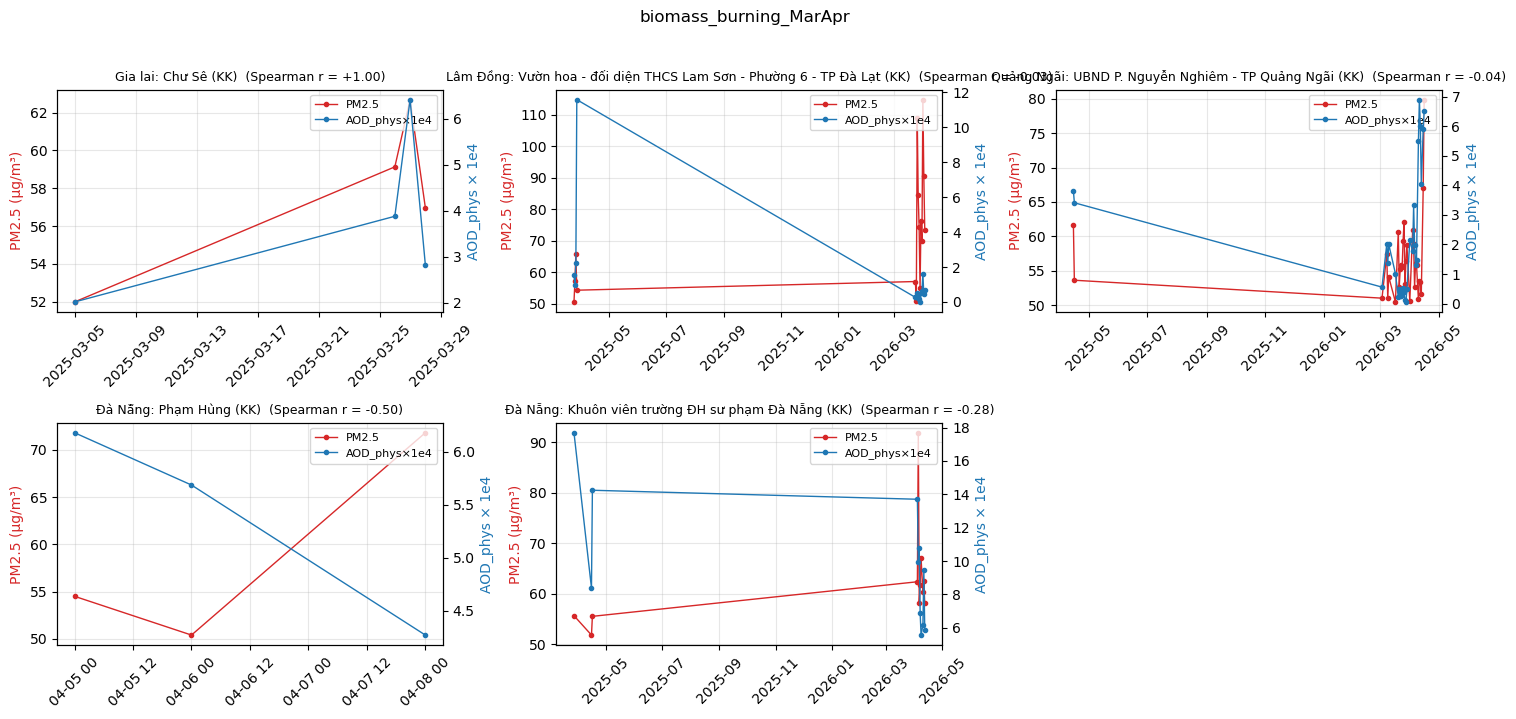

precip_washout: no qualifying stations.


In [ ]:
def _plot_event(ep_name: str, station_rows: pd.DataFrame, df_pairs: pd.DataFrame):
    stations = station_rows['station_name'].unique()
    if len(stations) == 0:
        print(f'{ep_name}: no qualifying stations.')
        return
    ncols = min(3, len(stations))
    nrows = (len(stations) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows),
                             squeeze=False)
    for ax, sn in zip(axes.flat, stations):
        sub = df_pairs[df_pairs['station_name'] == sn].sort_values('date')
        if sub.empty:
            ax.axis('off'); continue
        ax2 = ax.twinx()
        l1, = ax.plot(sub['date'], sub['pm25_daily'], color='C3', marker='.', lw=1, label='PM2.5')
        l2, = ax2.plot(sub['date'], sub['aod_phys_daily'] * 1e4, color='C0',
                        marker='.', lw=1, label='AOD_phys×1e4')
        ax.set_ylabel('PM2.5 (µg/m³)', color='C3'); ax2.set_ylabel('AOD_phys × 1e4', color='C0')
        r = float(station_rows[station_rows['station_name'] == sn]['spearman_r'].iloc[0])
        ax.set_title(f'{sn}  (Spearman r = {r:+.2f})', fontsize=9)
        ax.tick_params(axis='x', rotation=45); ax.grid(alpha=0.3)
        ax.legend([l1, l2], ['PM2.5', 'AOD_phys×1e4'], fontsize=8, loc='upper right')
    for ax in axes.flat[len(stations):]:
        ax.axis('off')
    fig.suptitle(ep_name, y=1.02, fontsize=12); fig.tight_layout(); plt.show()

if not cases.empty:
    for ep in ('severe_hanoi_haze', 'biomass_burning_MarApr', 'precip_washout'):
        rows = cases[cases['episode_type'] == ep]
        # Filter pairs to just the days/stations covered by this episode
        # (reconstruct the per-event filter to retrieve the daily series)
        if ep == 'severe_hanoi_haze':
            ep_pairs = pairs[(pairs['region'] == 'north') & (pairs['season'] == 'dry')
                              & (pairs['pm25_daily'] > 100)
                              & (pairs['aod_merged_daily'] > 1.0)]
        elif ep == 'biomass_burning_MarApr':
            ep_pairs = pairs[(pairs['month'].isin([3, 4])) & (pairs['pm25_daily'] > 50)]
        elif ep == 'precip_washout':
            parts = []
            for sn, grp in pairs[pairs['season'] == 'wet'].groupby('station_name'):
                g = grp.sort_values('date').copy()
                g['pm25_delta'] = g['pm25_daily'].diff()
                wash = g[g['pm25_delta'] <= -30]['date']
                if not wash.empty:
                    parts.append(g[g['date'].isin(wash)])
            ep_pairs = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
        else:
            ep_pairs = pd.DataFrame()
        _plot_event(ep, rows, ep_pairs)


## 4. Context — overall §8.1.6 coupling metrics

`pm25_coupling_metrics` (used by the Stage B §8.2 work) is also informative
here: the ALL row tells you whether the held-out merged-AOD-vs-PM2.5
Spearman r aggregated across stations crosses the §1.6 bar even without
filtering to specific events.


In [ ]:
if not pairs.empty:
    coupling = pm25_coupling_metrics(pairs)
    if not coupling.empty:
        cols = ['label', 'aod_type', 'n_stations', 'N',
                'pearson_r', 'spearman_r', 'ransac_r2', 'inlier_frac']
        # ALL row + per-region rows
        overall = coupling[coupling['label'].isin(['ALL'])
                            | coupling['label'].str.startswith('region=')]
        overall[cols].round(3)
